# Convolutional Neural Networks for Image Classification

**Author**: Jaycent Gunawan Ongris (Email: jaycentgunawanong@gmail.com; WA: 085757197839)

**Acknowledgement**: All materials are taken from https://d2l.ai/ and Python Machine Learning (3rd ed.) by Raschka & Mirjalili, unless stated explicitly.

**Name**: Mohamad Arvin Fadriansyah

**NPM**: 2006596996

There are two sections of this assignment: implementation (code) and essay. For the former section, answer directly in this notebook, whereas for the latter section, answer in a separate sheet.

Compress your notebook and PDF file into a ZIP archive. Your files must be named accordingly based on this format:
`[Kelas]_Tugas6_[NPM]_[NamaLengkap].[zip|ipynb|pdf]`.



---



In this assignment, you are going to learn how to build convolutional neural network **from scratch** by implementing all the layers one-by-one. PyTorch will be used for easier tensor operations and manipulations. Take a look at this documentation: https://pytorch.org/docs/stable/index.html. Relevant reading materials will further be given below.

If you are new to PyTorch, kindly read this module: https://pytorch.org/tutorials/beginner/basics/intro.html.

Here are some motivations on why you should learn PyTorch:


*   GPT is developed using PyTorch (https://github.com/openai/gpt-2)
*   LLaMA is developed using PyTorch (https://github.com/meta-llama/llama)
*   DeepSeek v3 is developed using PyTorch (https://github.com/deepseek-ai/DeepSeek-V3) 🤯
*   And many more... (read [this](https://blog.paperspace.com/why-use-pytorch-deep-learning-framework/) and [this](https://opencv.org/blog/learn-pytorch-in-2023/))





> 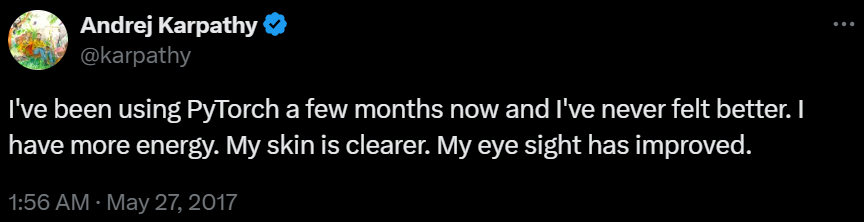




> https://x.com/karpathy/status/868178954032513024



## Requirements

In [97]:
!pip install datasets[vision]

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!pip install slalom-explanations

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from slalom_explanations import SLALOMLocalExplanantions

ModuleNotFoundError: No module named 'slalom_explanations.attribution_methods'

In [98]:
import torch
import numpy as np
from torch import nn
from tqdm import tqdm
from sklearn.metrics import classification_report

We are going to delve into the CNN components one-by-one, and finally build a full CNN for image classification task.

## Introduction to Convolutional Neural Network

Convolutional Neural Network (CNN) is a neural network architecture that is prominently used for image-related tasks, e.g., image classification, object detection, segmentation, and many more. Compared to Fully Connected Neural Networks (FCNNs), CNNs excel in processing image data due to their ability to capture spatial hierarchies and local patterns efficiently. While FCNNs treat input data as a flat vector, losing crucial spatial information, CNNs preserve the structure of images by applying convolutional filters (kernels) that scan local regions of the input. This allows CNNs to automatically learn features like edges, textures, and shapes, which are essential for understanding visual content. See https://sbme-tutorials.github.io/2018/cv/notes/4_week4.html for examples on several commonly known kernels and their applications.

One of the key advantages of CNNs is their parameter-sharing mechanism, which drastically reduces the number of parameters compared to FCNNs. This not only makes CNNs computationally efficient but also helps in preventing overfitting, especially when dealing with high-dimensional data like images. Additionally, CNNs incorporate pooling layers, which downsample the feature maps, further enhancing computational efficiency and providing translational invariance—meaning the network can recognize objects even if they appear in different positions within the image.

Specifically, CNN computes feature maps from an input image, where each element comes from a local patch of pixels in the input image, as visualized in the picture below.

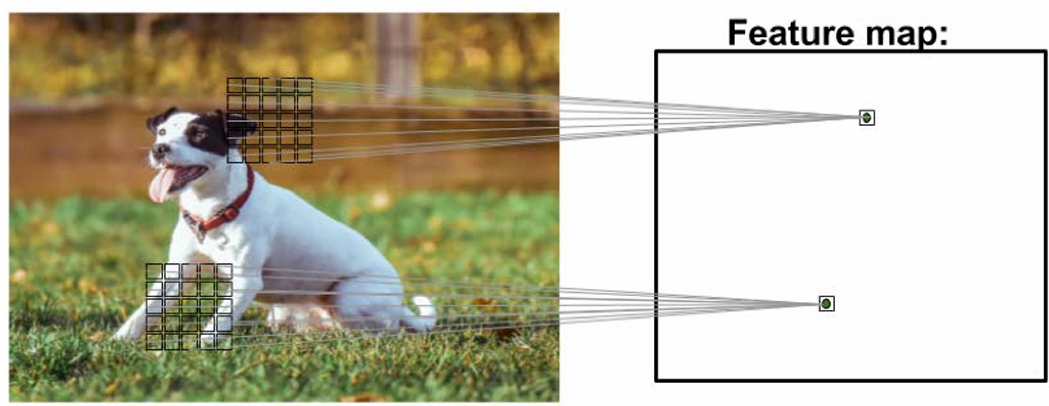

The original CNN architecure for image classification, introduced by Yann LeCun et al. in 1989, namely LeNet, was a pioneering model that laid the groundwork for modern CNNs. As seen below, the architecture comprises of multiple convolution and pooling layers, followed by multiple densely connected layers at the end for classification. We will delve into each layer subsequently.

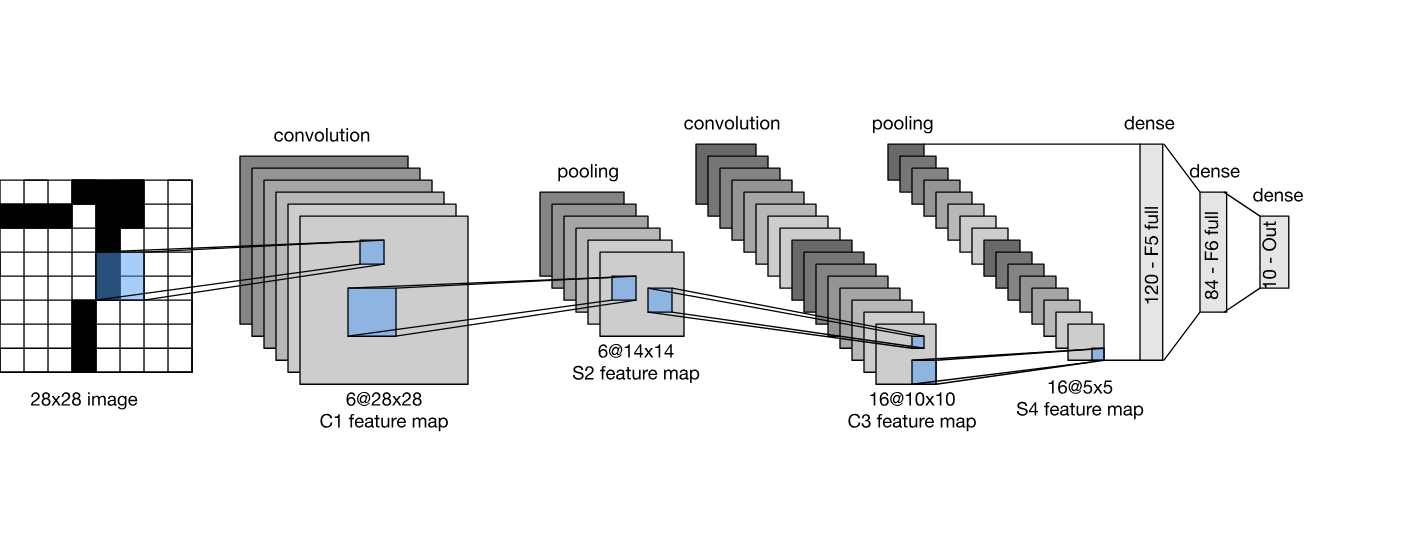

Read https://d2l.ai/chapter_convolutional-neural-networks/lenet.html#lenet for more detailed explanation of the architecture.

This [paper](https://arxiv.org/pdf/1603.07285) also explains the convolution arithmetic in a more detailed manner.

## Convolutional Layer

The name "convolutional layer" is actually a misnomer, since the operation it performs is more accurately described as cross-correlation. In this layer, an input tensor and a kernel tensor are combined to produce an output tensor through a cross-correlation operation. An example of the operation performed by such layer can be seen below, where the input is a two-dimensional tensor with a height of 3 and width of 3, and the height and width of the kernel are both 2.

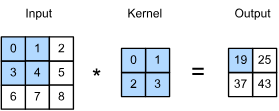

In the two-dimensional cross-correlation operation, we begin with the convolution window positioned at the upper-left corner of the input tensor and slide it across the input tensor, both from left to right and top to bottom. When the convolution window slides to a certain position, the input subtensor contained in that window and the kernel tensor are multiplied elementwise and the resulting tensor is summed up yielding a single scalar value. This result gives the value of the output tensor at the corresponding location.

Note that along each axis, the output size is slightly smaller than the input size. Because the kernel has width and height greater than $1$, we can only properly compute the cross-correlation for locations where the kernel fits wholly within the image, the output size is given by the input size $n_h \times n_w$ minus the size of the convolution kernel $k_h \times k_w$ via:

$$(n_h-k_h+1) \times (n_w-k_w+1)$$

A more advanced convolutional layer includes padding and stride, which offers more control over the size of the output. However, we are not going to implement that here. Read [this](https://d2l.ai/chapter_convolutional-neural-networks/padding-and-strides.html) page for a detailed explanation and see [this](https://miro.medium.com/v2/resize:fit:1400/1*s-Hm4M6au-bqW8VLL5qo3g.gif) visualization on how those work (sorry Colab can't display GIF properly).



> Note that the above output size calculation only applies for convolutions with padding = 0 and stride = 1. Read [this](https://arxiv.org/pdf/1603.07285) for other convolution cases with various padding and stride size.



Consider a toy implementation below on how to implement convolution operation step-by-step.

In [99]:
inp = torch.tensor(np.array([[0, 1, 2],
                             [3, 4, 5],
                             [6, 7, 8]]))
inp

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]], dtype=torch.int32)

In [100]:
filter = torch.tensor(np.array([[0, 1],
                                [2, 3]]))
filter

tensor([[0, 1],
        [2, 3]], dtype=torch.int32)

Tensor indexing (just like NumPy array indexing): https://saturncloud.io/blog/pytorch-tensor-indexing-a-comprehensive-guide/

In [101]:
# Let's perform the operation for the first entry of the result matrix
# Obtain the patch and filter (must be in the same size!)
patch = inp[0:2, 0:2]
patch, filter

(tensor([[0, 1],
         [3, 4]], dtype=torch.int32),
 tensor([[0, 1],
         [2, 3]], dtype=torch.int32))

In [102]:
# FYI: * operator in PyTorch perform element-wise multiplication
# If you want to perform matrix multiplication, use @ instead or torch.matmul
# Perform element-wise multiplication
result_matrix = patch * filter
result_matrix

tensor([[ 0,  1],
        [ 6, 12]], dtype=torch.int32)

In [103]:
# Sum it up
result_value = torch.sum(result_matrix)
result_value

tensor(19)

`torch.zeros` to generate tensor with zero elements: https://pytorch.org/docs/stable/generated/torch.zeros.html

In [104]:
# Now, construct a function to perform convolution
def conv2D(x, filter):
    """
    Melakukan operasi konvolusi 2D 'valid' pada tensor input x dengan filter (weight).
    
    Asumsi:
    - x: tensor 2D berukuran [H, W]
    - weight: tensor 2D berukuran [k, k]
    
    Return:
    - Tensor hasil konvolusi berukuran [H - k + 1, W - k + 1]
    """
    kernel_size = filter.shape[0]
    H, W = x.shape
    H_out = H - kernel_size + 1
    W_out = W - kernel_size + 1
    
    # List untuk menampung baris hasil konvolusi
    out_rows = []
    for i in range(H_out):
        row_vals = []
        for j in range(W_out):
            # Ambil patch dari input
            patch = x[i:i+kernel_size, j:j+kernel_size]
            # Lakukan perkalian elemen-demi-elemen dan penjumlahan
            conv_val = (patch * filter).sum()
            row_vals.append(conv_val)
        # Ubah baris menjadi tensor
        out_rows.append(torch.stack(row_vals))
    # Gabungkan semua baris menjadi tensor 2D
    return torch.stack(out_rows)


In [105]:
# Now, test it!
result = conv2D(inp, filter)
result

tensor([[19, 25],
        [37, 43]])

## Pooling Layer

Like convolutional layers, pooling operators consist of a fixed-shape window that is slid over all regions in the input according to its stride, computing a single output for each location traversed by the fixed-shape window (sometimes known as the pooling window). However, unlike the cross-correlation computation of the inputs and kernels in the convolutional layer, the pooling layer contains no parameters (there is no kernel). Instead, pooling operators are deterministic, typically calculating either the maximum or the average value of the elements in the pooling window. These operations are called maximum pooling (max-pooling for short) and average pooling, respectively.

As with the cross-correlation operator, we can think of the pooling window as starting from the upper-left of the input tensor and sliding across it from left to right and top to bottom. At each location that the pooling window hits, it computes the maximum or average value of the input subtensor in the window, depending on whether max or average pooling is employed.

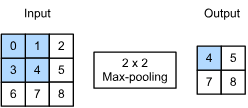

Just like convolutional layers, pooling layers can include stride. For stride = 1, the formula for the output size is the same as the one defined previously for convolutional layer. Read [this](https://arxiv.org/pdf/1603.07285) for other cases.

Next, let's delve into the implementation.

In [106]:
inp1 = torch.tensor(np.array([[0, 1, 2],
                              [3, 4, 5],
                              [6, 7, 8]]))
inp1

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]], dtype=torch.int32)

In [107]:
# Construct function for max pooling, the steps for populating the result
# matrix are similar to the previous convolution layer, except that
# there is no filter needed
import torch

def max_pooling(inp, kernel_size: int):
    """
    Melakukan max pooling dengan sliding window (stride = 1) pada tensor 2D.
    
    Parameter:
    - inp: Tensor 2D, misalnya berukuran [H, W].
    - kernel_size: Ukuran blok pooling (misalnya 2 untuk blok 2x2).
    
    Return:
    - Tensor 2D hasil max pooling dengan ukuran [H - kernel_size + 1, W - kernel_size + 1].
    """
    H, W = inp.shape
    H_out = H - kernel_size + 1
    W_out = W - kernel_size + 1
    out_rows = []
    for i in range(H_out):
        row_vals = []
        for j in range(W_out):
            # Ambil patch dengan ukuran kernel_size x kernel_size
            patch = inp[i:i+kernel_size, j:j+kernel_size]
            # Dapatkan nilai maksimum pada patch
            row_vals.append(torch.max(patch))
        out_rows.append(torch.stack(row_vals))
    return torch.stack(out_rows)





In [108]:
# Now, test it!
result1 = max_pooling(inp1, 2)
result1

tensor([[4, 5],
        [7, 8]], dtype=torch.int32)

Now, **implement** a similar function which can perform both max and average pooling. The `mode` parameter can receive either `avg` or `max` to indicate whether the max or average pooling mode will be activated.

In [109]:
import torch

def pooling(inp, kernel_size: int, mode: str):
    """
    Melakukan pooling (max atau average) pada input 2D dengan sliding window (stride = 1).

    Parameter:
    - inp: 2D tensor atau list of lists yang merepresentasikan input.
    - kernel_size: ukuran kernel pooling (misalnya 2 berarti blok 2x2).
    - mode: string 'max' untuk max pooling atau 'avg' untuk average pooling.

    Return:
    - Jika inp adalah tensor, output berupa tensor 2D hasil pooling.
      Jika inp adalah list of lists, output berupa list of lists hasil pooling.
    """
    # Dapatkan ukuran input
    if hasattr(inp, 'shape'):
        H_inp, W_inp = inp.shape[0], inp.shape[1]
    else:
        H_inp, W_inp = len(inp), len(inp[0])
    
    # Hitung ukuran output dengan stride = 1
    H_out = H_inp - kernel_size + 1
    W_out = W_inp - kernel_size + 1

    # Jika input merupakan tensor PyTorch
    if hasattr(inp, 'shape'):
        out_rows = []
        for i in range(H_out):
            row_vals = []
            for j in range(W_out):
                # Ambil patch dengan ukuran kernel_size x kernel_size
                patch = inp[i:i+kernel_size, j:j+kernel_size]
                # Pilih pooling berdasarkan mode
                if mode == "max":
                    row_vals.append(torch.max(patch))
                elif mode == "avg":
                    row_vals.append(torch.mean(patch))
                else:
                    raise ValueError("Mode harus 'max' atau 'avg'")
            out_rows.append(torch.stack(row_vals))
        return torch.stack(out_rows)
    
    # Jika input merupakan list of lists
    else:
        out = []
        for i in range(H_out):
            row_result = []
            for j in range(W_out):
                block = []
                for m in range(kernel_size):
                    for n in range(kernel_size):
                        block.append(inp[i + m][j + n])
                if mode == "max":
                    pooled_val = max(block)
                elif mode == "avg":
                    pooled_val = sum(block) / len(block)
                else:
                    raise ValueError("Mode harus 'max' atau 'avg'")
                row_result.append(pooled_val)
            out.append(row_result)
        return out


In [110]:
# Test your function
pooling(inp1, 2, "max")

tensor([[4, 5],
        [7, 8]], dtype=torch.int32)

We are going to implement all those functions as layers. Therefore, define a class inherited from `nn.Module` which serves as the layer we are going to invoke later. See https://d2l.ai/chapter_builders-guide/custom-layer.html.

In [134]:
# Define convolutional layer
# Bias is added
class MyConv2D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        # Initialize filter with Glorot's initialization
        # For reference: https://pytorch.org/docs/stable/_modules/torch/nn/init.html#xavier_uniform_
        # Important to choose good initial parameters, otherwise your model will not converge
        self.weights = nn.Parameter(torch.nn.init.xavier_uniform_(torch.empty(kernel_size, kernel_size)))
        # Initialize bias
        self.bias = nn.Parameter(torch.rand(1))

    def forward(self, x):
        # self.bias has different size with the result of conv2D
        # But it does not return any errors on size incompatibility. How?
        # Read about tensor broadcasting: https://www.geeksforgeeks.org/tensor-broadcasting/
        return conv2D(x, self.weights) + self.bias

sample_conv2d = MyConv2D(kernel_size=2)
res1 = sample_conv2d(inp1)
res1

tensor([[2.8269, 3.7201],
        [5.5065, 6.3997]], grad_fn=<AddBackward0>)

In [137]:
# Define pooling layer
class MyPooling(nn.Module):
    def __init__(self, kernel_size, mode):
        super().__init__()
        self.kernel_size = kernel_size
        self.mode = mode

    def forward(self, x):
        # Just call your predefined function
        return pooling(x, self.kernel_size, self.mode)

sample_pooling = MyPooling(kernel_size=2, mode='max')
res2 = sample_pooling(res1)
res2

tensor([[6.3997]], grad_fn=<StackBackward0>)

Remember that we are going to use linear layers for our CNN for classification architecture. We are going to implement this linear layer below, with the formula of $y=xA^T + b$.

In [149]:
# Define linear layer
class MyLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Initialize weight matrix
        self.weights = nn.Parameter(torch.nn.init.xavier_uniform_(torch.empty(out_features, in_features)))
        self.bias = nn.Parameter(torch.rand(out_features))

    def forward(self, x):
        return torch.matmul(x, self.weights.T) + self.bias

In [151]:
# Linear layer example with input of 4 and output of 2
# We flatten the result from res1 first
res1_reshaped = res1.reshape(-1)
print(res1_reshaped)
print()

sample_lin = MyLinear(in_features=4, out_features=2)
res3 = sample_lin(res1_reshaped)
res3

tensor([2.8269, 3.7201, 5.5065, 6.3997], grad_fn=<ViewBackward0>)



tensor([0.8207, 0.2481], grad_fn=<AddBackward0>)

Next, we are going to implement two activation functions we are going to include in the architecture: ReLU and Softmax (for the classification head). Both follow these formulas below.

$$\text{ReLU}(x)=\max{(0, x)}$$


$$\text{softmax}(x_i)=\frac{\exp{(x_i)}}{\sum_{j=1}^{n} \exp{(x_j)}}$$

In [154]:
# Define ReLU layer
class MyReLU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.clamp(x, min=0)

sample_relu = MyReLU()
res4 = sample_relu(res1_reshaped)
res4

tensor([2.8269, 3.7201, 5.5065, 6.3997], grad_fn=<ClampBackward1>)

For softmax, we can process the input directly in the form of tensor.

In [156]:
# Define softmax layer
class MySoftmax(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        numerator = torch.exp(x)
        denominator = torch.sum(torch.exp(x))
        return numerator / denominator

sample_softmax = MySoftmax()
res5 = sample_softmax(res1_reshaped)
res5

tensor([0.0186, 0.0455, 0.2718, 0.6640], grad_fn=<DivBackward0>)

In [157]:
# One of the characteristics of softmax is that the sum of all
# tensor elements is 1
torch.sum(res5)

tensor(1.0000, grad_fn=<SumBackward0>)

## Simple CNN for (Grayscale) Image Classification

In this section, we will build a PyTorch model for performing image classification. The model is a simplified version of LeNet. We are going to use MNIST dataset to test the performance of our model.

In [158]:
from datasets import load_dataset

dataset = load_dataset("ylecun/mnist")
dataset

Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 272992.02 examples/s]


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [159]:
# example
class_images = {i: None for i in range(10)}

for item in dataset["test"]:
    label = item['label']
    if class_images[label] is None:
        class_images[label] = item['image']
    if all([img is not None for img in class_images.values()]):
        break

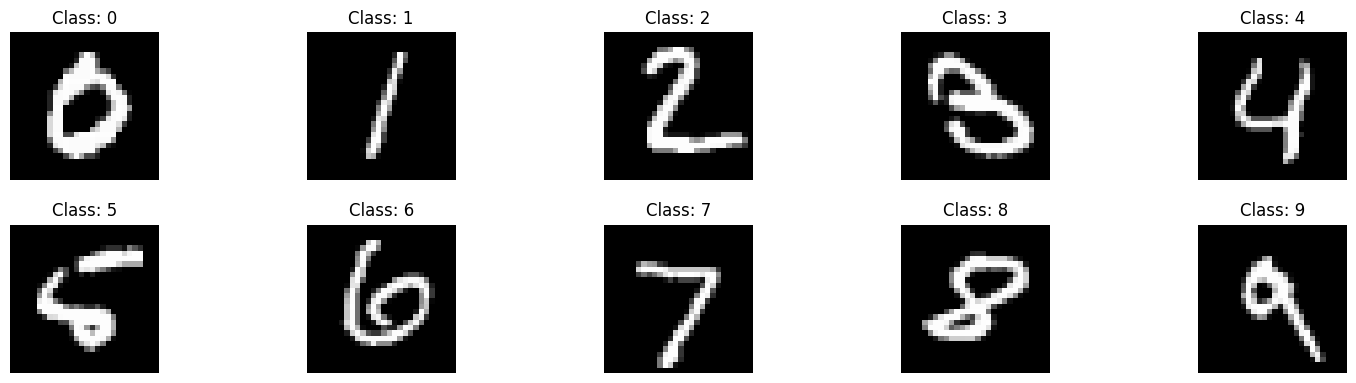

In [160]:
import matplotlib.pyplot as plt

def visualize_class_images(class_images):
    num_classes = len(class_images)
    cols = 5
    rows = (num_classes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 2 * rows))
    fig.tight_layout()

    for i, (class_label, image) in enumerate(class_images.items()):
        row = i // cols
        col = i % cols
        axes[row, col].imshow(np.array(image), cmap='gray')
        axes[row, col].set_title(f"Class: {class_label}")
        axes[row, col].axis('off')

    for i in range(num_classes, rows * cols):
        fig.delaxes(axes.flatten()[i])

    plt.show()

visualize_class_images(class_images)

In [161]:
train_data = dataset["train"]
test_data = dataset["test"]

In [162]:
# Too big, sampling
# May take a little bit longer
from collections import defaultdict

def stratified_sample(dataset, target_size):
    class_groups = defaultdict(list)
    for example in dataset:
        class_groups[example["label"]].append(example)

    num_classes = len(class_groups)
    samples_per_class = target_size // num_classes

    reduced_data = []
    for label, examples in class_groups.items():
        reduced_data.extend(examples[:samples_per_class])

    return reduced_data

reduced_train_data = stratified_sample(train_data, 1000)
reduced_test_data = stratified_sample(test_data, 100)

In [163]:
# Normalize image and convert label to tensor
def preprocess(example):
    example["image"] = torch.tensor(np.array(example["image"])) / 255.0

    # Convert into one hot tensor
    class_label = example["label"]
    one_hot_tensor = torch.zeros(10)
    one_hot_tensor[class_label] = 1

    example["label"] = one_hot_tensor
    return example

reduced_train_data = [preprocess(example) for example in reduced_train_data]
reduced_test_data = [preprocess(example) for example in reduced_test_data]

In [164]:
img_sample = reduced_train_data[0]["image"]
label_sample = reduced_train_data[0]["label"]
img_sample.shape, label_sample

(torch.Size([28, 28]), tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]))

For multiclass classification, remember that we are going to use the categorical cross entropy loss function, which is defined as follows, with $\hat{y}_i$ and $y_i$ as predicted probability and ground truth binary label of class $i$, respectively. $C$ is the number of classes.

$$L(\hat{y}, y)=-\sum_{i=1}^{C} y_i \log{(\hat{y}_i)}$$

In [165]:
import random

def cce_loss(pred, label, eps=1e-9):
    # We perform CCE computation
    # eps is a very small number to prevent log(0)
    return -torch.sum(label * torch.log(pred + eps))

class MySimpleCNN(nn.Module):
    def __init__(self):
        super(MySimpleCNN, self).__init__()

        # Define convolution and pooling layers below
        self.conv1 = MyConv2D(5)
        self.pool1 = MyPooling(2, "avg")
        self.conv2 = MyConv2D(5)
        self.pool2 = MyPooling(2, "avg")
        self.conv3 = MyConv2D(5)
        self.pool3 = MyPooling(2, "avg")

        # Define activation functions below
        self.relu = MyReLU()
        self.softmax = MySoftmax()

        # Define linear layers below
        self.lin1 = MyLinear(13 * 13, 120)
        self.lin2 = MyLinear(120, 84)
        self.lin3 = MyLinear(84, 10)

    def forward(self, X):
        y = self.conv1(X)
        y = self.pool1(y)
        y = self.conv2(y)
        y = self.pool2(y)
        y = self.conv3(y)
        y = self.pool3(y)

        # Result of this operation is 13 x 13 tensor
        # Flatten it first
        y = y.reshape(-1)

        y = self.relu(self.lin1(y))
        y = self.relu(self.lin2(y))

        y = self.softmax(self.lin3(y))
        return y

def train_model(model, train_data, learning_rate=3e-3, num_epochs=2):
    model.train()
    step = 0

    random.shuffle(train_data)

    # Our model does not support batch processing, so we can only do
    # stochastic gradient descent
    for epoch in range(num_epochs):
        for i, data in enumerate(train_data):
            model.zero_grad()

            img = data["image"]
            label = data["label"]

            # Perform forward propagation
            output = model(img)
            loss = cce_loss(output, label)

            # Perform back propagation
            loss.backward()

            # Update parameters
            with torch.no_grad():
                for param in model.parameters():
                    param -= learning_rate * param.grad

            # Logging
            if i % 100 == 0:
                print(f"Step: {step}, Epoch: {epoch}/{num_epochs}, Loss: {loss.item()}")

            step += 1

model = MySimpleCNN()
train_model(model, reduced_train_data)

Step: 0, Epoch: 0/2, Loss: 4.820108413696289
Step: 100, Epoch: 0/2, Loss: 0.22645506262779236
Step: 200, Epoch: 0/2, Loss: 1.8586708307266235
Step: 300, Epoch: 0/2, Loss: 0.597241222858429
Step: 400, Epoch: 0/2, Loss: 0.07933776080608368
Step: 500, Epoch: 0/2, Loss: 0.3451286852359772
Step: 600, Epoch: 0/2, Loss: 3.7699851989746094
Step: 700, Epoch: 0/2, Loss: 2.6027679443359375
Step: 800, Epoch: 0/2, Loss: 1.0193147659301758
Step: 900, Epoch: 0/2, Loss: 0.023421037942171097
Step: 1000, Epoch: 1/2, Loss: 0.2762722373008728
Step: 1100, Epoch: 1/2, Loss: 0.0034129382111132145
Step: 1200, Epoch: 1/2, Loss: 0.11887132376432419
Step: 1300, Epoch: 1/2, Loss: 0.19625532627105713
Step: 1400, Epoch: 1/2, Loss: 0.0003461840969976038
Step: 1500, Epoch: 1/2, Loss: 0.13161395490169525
Step: 1600, Epoch: 1/2, Loss: 3.549142360687256
Step: 1700, Epoch: 1/2, Loss: 0.1222681999206543
Step: 1800, Epoch: 1/2, Loss: 0.8838061094284058
Step: 1900, Epoch: 1/2, Loss: 0.00031315223895944655


The code below is to set the model to the evaluation mode.

In [166]:
model.eval()

MySimpleCNN(
  (conv1): MyConv2D()
  (pool1): MyPooling()
  (conv2): MyConv2D()
  (pool2): MyPooling()
  (conv3): MyConv2D()
  (pool3): MyPooling()
  (relu): MyReLU()
  (softmax): MySoftmax()
  (lin1): MyLinear()
  (lin2): MyLinear()
  (lin3): MyLinear()
)

In [167]:
pred_labels = []
gt_labels = []

for data in tqdm(reduced_test_data):
    img = data["image"]
    label = data["label"]

    output = model(img)
    pred_labels.append(torch.argmax(output).item())
    gt_labels.append(torch.argmax(label).item())

100%|██████████| 100/100 [00:06<00:00, 14.48it/s]


In [168]:
print(classification_report(gt_labels, pred_labels))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       1.00      1.00      1.00        10
           2       0.47      0.90      0.62        10
           3       1.00      0.80      0.89        10
           4       1.00      1.00      1.00        10
           5       0.89      0.80      0.84        10
           6       0.86      0.60      0.71        10
           7       0.70      0.70      0.70        10
           8       1.00      0.90      0.95        10
           9       1.00      0.90      0.95        10

    accuracy                           0.85       100
   macro avg       0.89      0.85      0.86       100
weighted avg       0.89      0.85      0.86       100



Suppose that we are building another image classification model, but this time we are not using convolution layers. Instead, we flatten the image directly. Let's compare the number of parameters.

In [169]:
class MyDummyFCN(nn.Module):
    def __init__(self):
        super(MyDummyFCN, self).__init__()

        # Image size is 28 x 28
        self.lin1 = nn.Linear(28 * 28, 120)
        self.lin2 = nn.Linear(120, 84)
        self.lin3 = nn.Linear(84, 10)

dumfcn = MyDummyFCN()
dumfcn_trainable_params = sum(p.numel() for p in dumfcn.parameters() if p.requires_grad)
cnn_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Number of FCN parameters: {dumfcn_trainable_params}")
print(f"Number of CNN parameters: {cnn_trainable_params}")

Number of FCN parameters: 105214
Number of CNN parameters: 31492


See how efficient CNN is? :)

## Advanced CNN Layers

Previously, our model can only work with grayscale images, i.e., there is only one color channel for each image. This is in contrast to color images, which have multiple channels that comprise each image. For example, an RGB image consists of three channels: R, G, and B. Therefore, each image with the width and height $w$ and $h$, respectively, will have the size of $3 \times h \times w$, instead of just $h \times w$ like in previous examples.

When the number of channel $c$ is more than one, a kernel with size $k_h \times k_w$ is needed for every input channel. Thus, concatenating these kernel tensors yields a convolution kernel of shape $c \times k_h \times k_w$. Since the input and convolution kernel each has $c$ channels, we can perform a cross-correlation operation on the two-dimensional tensor of the input and the two-dimensional tensor of the convolution kernel for each channel, adding the $c$ results together (summing over the channels) to yield a two-dimensional tensor. This is the result of a two-dimensional cross-correlation between a multi-channel input and a multi-input-channel convolution kernel. The visualization can be seen below.

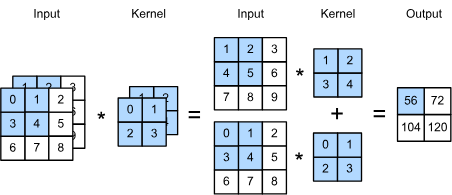

$(1\times1+2\times2+4\times3+5\times4)+(0\times0+1\times1+3\times2+4\times3)=56$

Define a function to perform convolution for images with multiple input channels.

In [ ]:
def conv2D_multiple_input(inputs, kernels):
    """
    Melakukan operasi konvolusi 2D pada input dengan banyak channel.
    
    Parameter:
    - inputs: Tensor 3D dengan shape [C, H, W] di mana C adalah jumlah channel,
              H dan W adalah dimensi spasial.
    - kernels: Tensor 3D dengan shape [C, k, k] yang berisi kernel untuk tiap channel.
    
    Proses:
    - Untuk setiap channel, dilakukan operasi konvolusi 2D "valid" (tanpa padding, stride=1)
      antara input channel tersebut dan kernel yang sesuai.
    - Hasil dari tiap channel dijumlahkan (element-wise) untuk menghasilkan output akhir.
    
    Return:
    - Tensor hasil konvolusi dengan shape [H - k + 1, W - k + 1].
    """
    # Jumlah channel, tinggi, dan lebar input
    C, H, W = inputs.shape
    # Ukuran kernel (diasumsikan kernel berbentuk persegi)
    k = kernels.shape[1]
    # Ukuran output
    H_out = H - k + 1
    W_out = W - k + 1
    
    # Inisialisasi output dengan nol
    output = torch.zeros(H_out, W_out)
    
    # Looping untuk tiap channel
    for c in range(C):
        # Looping posisi valid di dalam channel
        for i in range(H_out):
            for j in range(W_out):
                # Ambil patch dari channel ke-c
                patch = inputs[c, i:i+k, j:j+k]
                # Lakukan perkalian elemen-demi-elemen dengan kernel untuk channel ke-c
                # dan tambahkan hasilnya ke output
                output[i, j] += torch.sum(patch * kernels[c])
                
    return output


sample_mult_inp = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
               [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
sample_kernels = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

conv2D_multiple_input(sample_mult_inp, sample_kernels)

tensor([[ 56.,  72.],
        [104., 120.]])

In this section, modify the previous PyTorch convolution layer to accomodate RGB images according to the image shown previously (note that the image only consists of inputs with 2 layers, so please adjust your implementation!). Use the `conv2D_multiple_input`.


**Instruction**: Add bias on the last operation only, i.e., the output layer. For instance, on the example above, with the bias $1$, the result would be:
$$
\begin{bmatrix}
57 & 73 \\
105 & 121
\end{bmatrix}$$

In [176]:
class MyRGBConv2DMultInput(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        empty_kernel = torch.empty(3, kernel_size, kernel_size)
        self.weights = nn.Parameter(torch.nn.init.xavier_uniform_(empty_kernel))
        self.bias = nn.Parameter(torch.rand(1))

    def forward(self, x):
        return conv2D_multiple_input(x, self.weights) + self.bias

In [180]:
sample_conv_multinp = MyRGBConv2DMultInput(2)
sample_conv_multinp(sample_mult_inp)

tensor([[1.6169, 2.2930],
        [3.6453, 4.3214]], grad_fn=<AddBackward0>)

However, since kernels act as feature extractors from images, implementing multiple kernels enables the model to learn various features. The result is a tensor with multiple output channels.

Denote by $c_i$ and $c_o$ the number of input and output channels, respectively, and by $k_h$ and $k_w$ the height and width of the kernel. To get an output with multiple channels, we can create a kernel tensor of shape $c_i \times k_h \times k_w$ for every output channel. We concatenate them on the output channel dimension, so that the shape of the convolution kernel is $c_o \times c_i \times k_h \times k_w$. In cross-correlation operations, the result on each output channel is calculated from the convolution kernel corresponding to that output channel and takes input from all channels in the input tensor.

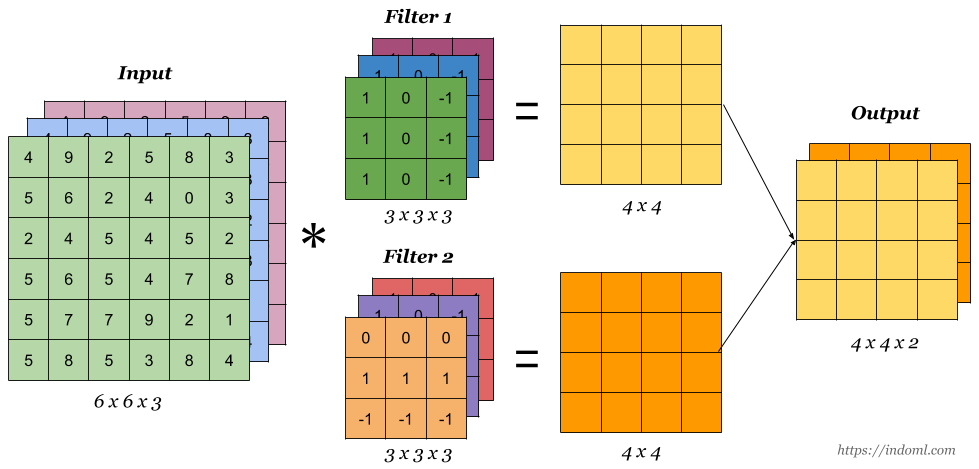

Source: https://i.sstatic.net/rsKBz.png

Define a function to perform convolution with multiple input and output channels. Reuse `conv2D_multiple_input`.

In [187]:
# See this example of multiple input-output kernels
sample_mult_kernels = torch.stack((sample_kernels, sample_kernels + 1, sample_kernels + 2), 0)
sample_mult_kernels

tensor([[[[0., 1.],
          [2., 3.]],

         [[1., 2.],
          [3., 4.]]],


        [[[1., 2.],
          [3., 4.]],

         [[2., 3.],
          [4., 5.]]],


        [[[2., 3.],
          [4., 5.]],

         [[3., 4.],
          [5., 6.]]]])

In [188]:
sample_mult_kernels.shape

torch.Size([3, 2, 2, 2])

Hint: Iterate over the first dimension over `sample_mult_kernels` to obtain each filter and perform multiple input convolution with the given input. Stack the result for each filter as the first dimension, i.e., `torch.stack(..., 0)`.

In [189]:
def conv2D_multiple_input_output(inputs, kernels):
    """
    Melakukan operasi konvolusi 2D pada input dengan banyak channel dan menghasilkan output dengan banyak channel.
    
    Parameter:
    - inputs: Tensor 3D berukuran [c_i, H, W]
    - kernels: Tensor 4D berukuran [c_o, c_i, k_h, k_w]
    
    Proses:
    - Untuk setiap output channel (filter) di kernels, lakukan konvolusi pada seluruh input channel,
      kemudian jumlahkan hasilnya.
    
    Return:
    - Tensor hasil konvolusi dengan bentuk [c_o, H - k_h + 1, W - k_w + 1]
    """
    # Dimensi dari kernels
    c_o, c_i, k_h, k_w = kernels.shape
    # Dimensi dari input
    _, H, W = inputs.shape
    # Ukuran output (valid convolution, stride=1)
    H_out = H - k_h + 1
    W_out = W - k_w + 1
    
    output_filters = []  # Untuk menyimpan output tiap filter (output channel)
    
    # Iterasi untuk tiap output channel/filter
    for out_idx in range(c_o):
        # Ambil kernel untuk output channel ini, berukuran [c_i, k_h, k_w]
        kernel = kernels[out_idx]
        # Inisialisasi tensor output untuk filter ini
        out_channel = torch.zeros(H_out, W_out)
        # Lakukan konvolusi untuk setiap channel input
        for ch in range(c_i):
            # Kernel untuk channel ke-ch dari filter ini
            kernel_ch = kernel[ch]
            # Input channel ke-ch
            input_ch = inputs[ch]
            # Lakukan sliding window pada input channel ini
            for i in range(H_out):
                for j in range(W_out):
                    patch = input_ch[i:i+k_h, j:j+k_w]
                    out_channel[i, j] += torch.sum(patch * kernel_ch)
        output_filters.append(out_channel)
    
    # Stack semua output channel menjadi satu tensor, dengan output shape [c_o, H_out, W_out]
    return torch.stack(output_filters, 0)


In [191]:
conv2D_multiple_input_output(sample_mult_inp, sample_mult_kernels)

tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])

Construct the equivalent PyTorch layer. Add bias at the output result only.

In [196]:
class MyRGBConv2DMultInputOutput(nn.Module):
    def __init__(self, kernel_size, num_kernels):
        super().__init__()
        # empty_kernel = torch.empty(num_kernels, 3, kernel_size, kernel_size)
        empty_kernel = torch.empty(num_kernels, 2, kernel_size, kernel_size)
        self.weights = nn.Parameter(torch.nn.init.xavier_uniform_(empty_kernel))
        self.bias = nn.Parameter(torch.rand(1))

    def forward(self, x):
        return conv2D_multiple_input_output(x, self.weights) + self.bias

In [200]:
sample_conv_multinpout = MyRGBConv2DMultInputOutput(2, 3)
sample_conv_multinpout(sample_mult_inp)

tensor([[[ 5.1148,  6.4221],
         [ 9.0368, 10.3441]],

        [[ 0.8097,  1.1782],
         [ 1.9151,  2.2836]],

        [[-2.3356, -3.6040],
         [-6.1409, -7.4093]]], grad_fn=<AddBackward0>)

For the last one, modify the pooling layer. When processing multi-channel input data, the pooling layer pools each input channel separately, rather than summing the inputs up over channels as in a convolutional layer. This means that the number of output channels for the pooling layer is the same as the number of input channels.

In [202]:
def pooling_mult(inputs, kernel_size: int, mode: str):
    """
    Melakukan pooling pada input multi-channel dengan sliding window (stride = 1).
    Pooling dilakukan secara independen pada tiap channel.
    
    Parameter:
    - inputs: Tensor 3D berukuran [c, H, W]
    - kernel_size: ukuran blok pooling (misalnya 2 berarti blok 2x2)
    - mode: 'max' untuk max pooling atau 'avg' untuk average pooling
    
    Return:
    - Tensor hasil pooling dengan bentuk [c, H - kernel_size + 1, W - kernel_size + 1]
    """
    c, H, W = inputs.shape
    H_out = H - kernel_size + 1
    W_out = W - kernel_size + 1
    output_channels = []
    
    # Proses pooling untuk setiap channel secara independen
    for ch in range(c):
        out_channel = torch.zeros(H_out, W_out, device=inputs.device, dtype=inputs.dtype)
        input_ch = inputs[ch]
        for i in range(H_out):
            for j in range(W_out):
                patch = input_ch[i:i+kernel_size, j:j+kernel_size]
                if mode == "avg":
                    pooled_val = torch.mean(patch)
                elif mode == "max":
                    pooled_val = torch.max(patch)
                else:
                    raise ValueError("Mode harus 'avg' atau 'max'")
                out_channel[i, j] = pooled_val
        output_channels.append(out_channel)
        
    return torch.stack(output_channels, dim=0)


pooling_mult(sample_mult_inp, 2, "avg")

tensor([[[2., 3.],
         [5., 6.]],

        [[3., 4.],
         [6., 7.]]])

Implement it as a PyTorch layer. Replace the previous one with this. Make sure this layer works for both single and multiple channels images.

In [203]:
sample_single = torch.tensor([[1., 2., 3.], [4., 5., 6.], [7., 8., 9.]])
sample_single

tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])

In [204]:
# Define multiple input-output pooling layer
class MyPooling(nn.Module):
    def __init__(self, kernel_size, mode):
        super().__init__()
        self.kernel_size = kernel_size
        self.mode = mode

    def forward(self, x):
        if len(x.shape) == 2:
            return pooling(x, self.kernel_size, self.mode)
        else:
            return pooling_mult(x, self.kernel_size, self.mode)

sample_pooling = MyPooling(kernel_size=2, mode='avg')
res_single = sample_pooling(sample_single)
print(f"Single channel: \n{res_single}\n")

res_mult = sample_pooling(sample_mult_inp)
print(f"Multiple channels: \n{res_mult}")

Single channel: 
tensor([[3., 4.],
        [6., 7.]])

Multiple channels: 
tensor([[[2., 3.],
         [5., 6.]],

        [[3., 4.],
         [6., 7.]]])


## Advanced CNN for Color Image Classification

We will use the CIFAR-10 dataset. This dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class

In [205]:
dataset = load_dataset("uoft-cs/cifar10")
dataset

Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 142703.69 examples/s]


DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [206]:
# example
class_images = {i: None for i in range(10)}

for item in dataset["test"]:
    label = item['label']
    if class_images[label] is None:
        class_images[label] = item['img']
    if all([img is not None for img in class_images.values()]):
        break

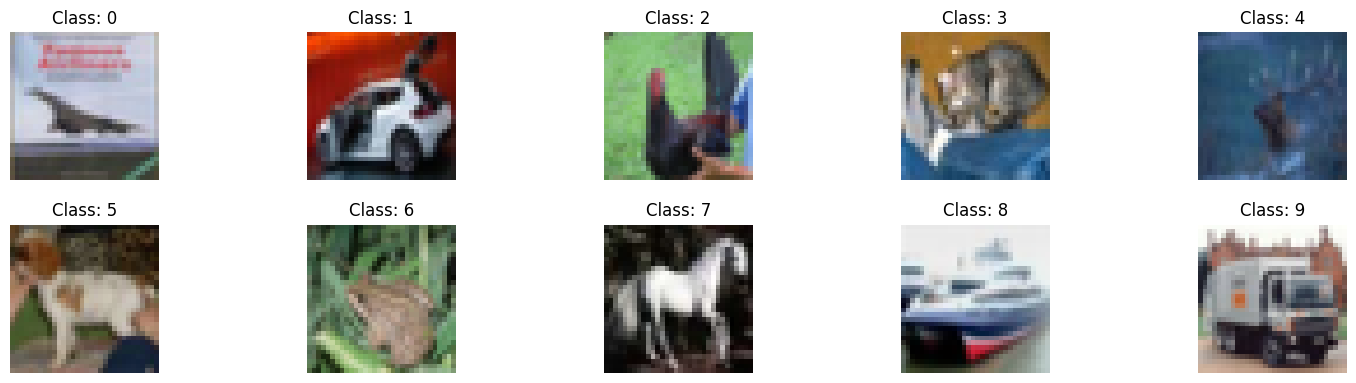

In [207]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_class_images(class_images):
    num_classes = len(class_images)
    cols = 5
    rows = (num_classes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 2 * rows))
    fig.tight_layout()

    for i, (class_label, image) in enumerate(class_images.items()):
        row = i // cols
        col = i % cols
        axes[row, col].imshow(np.array(image), cmap='gray')
        axes[row, col].set_title(f"Class: {class_label}")
        axes[row, col].axis('off')

    for i in range(num_classes, rows * cols):
        fig.delaxes(axes.flatten()[i])

    plt.show()

visualize_class_images(class_images)

In [208]:
train_data = dataset["train"]
test_data = dataset["test"]

reduced_train_data = stratified_sample(train_data, 200)
reduced_test_data = stratified_sample(test_data, 50)

In [209]:
# Normalize image and convert label to tensor
def preprocess(example):
    img = torch.tensor(np.array(example["img"])) / 255.0
    # Change the size from (32, 32, 3) to (3, 32, 32)
    img = img.permute(2, 0, 1)
    example["img"] = img

    # Convert into one hot tensor
    class_label = example["label"]
    one_hot_tensor = torch.zeros(10)
    one_hot_tensor[class_label] = 1

    example["label"] = one_hot_tensor
    return example

reduced_train_data = [preprocess(example) for example in reduced_train_data]
reduced_test_data = [preprocess(example) for example in reduced_test_data]

In [210]:
img_sample = reduced_train_data[0]["img"]
label_sample = reduced_train_data[0]["label"]
img_sample.shape, label_sample

(torch.Size([3, 32, 32]), tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [211]:
import random

def cce_loss(pred, label, eps=1e-9):
    # We perform CCE computation
    # eps is a very small number to prevent log(0)
    return -torch.sum(label * torch.log(pred + eps))

class MyAdvancedCNN(nn.Module):
    def __init__(self):
        super(MyAdvancedCNN, self).__init__()

        # Define convolution and pooling layers below
        self.conv1 = MyRGBConv2DMultInputOutput(5, 2)
        self.pool1 = MyPooling(8, "avg")
        self.conv2 = MyRGBConv2DMultInputOutput(5, 2)
        self.pool2 = MyPooling(8, "avg")

        # Define activation functions below
        self.relu = MyReLU()
        self.softmax = MySoftmax()

        # Define linear layers below
        self.lin1 = MyLinear(2 * 10 * 10, 80)
        self.lin2 = MyLinear(80, 20)
        self.lin3 = MyLinear(20, 10)

    def forward(self, X):
        y = self.conv1(X)
        y = self.pool1(y)
        y = self.conv2(y)
        y = self.pool2(y)
        # print(y.shape)

        # Previous size: 2 x 10 x 10
        # Flatten the tensor
        y = y.reshape(-1)

        y = self.relu(self.lin1(y))
        y = self.relu(self.lin2(y))

        y = self.softmax(self.lin3(y))
        return y

def train_model(model, train_data, learning_rate=3e-3, num_epochs=2):
    model.train()

    step = 0

    random.shuffle(train_data)

    # Our model does not support batch processing, so we can only do
    # stochastic gradient descent
    for epoch in range(num_epochs):
        for i, data in enumerate(train_data):
            model.zero_grad()

            img = data["img"]
            label = data["label"]

            # Perform forward propagation
            output = model(img)
            loss = cce_loss(output, label)

            # Perform back propagation
            loss.backward()

            # Update parameters
            with torch.no_grad():
                for param in model.parameters():
                    param -= learning_rate * param.grad

            # Logging
            if i % 50 == 0:
                print(f"Step: {step}, Epoch: {epoch}/{num_epochs}, Loss: {loss.item()}")

            step += 1

model = MyAdvancedCNN()
train_model(model, reduced_train_data)

Step: 0, Epoch: 0/2, Loss: 6.35232400894165
Step: 50, Epoch: 0/2, Loss: 3.296754837036133
Step: 100, Epoch: 0/2, Loss: 2.0493059158325195
Step: 150, Epoch: 0/2, Loss: 2.044292688369751
Step: 200, Epoch: 1/2, Loss: 2.59183406829834
Step: 250, Epoch: 1/2, Loss: 2.644528388977051
Step: 300, Epoch: 1/2, Loss: 2.0421688556671143
Step: 350, Epoch: 1/2, Loss: 2.1791343688964844


The training (on CPU) can take approximately 15 minutes. If you are working on Google Colab or Kaggle Notebook, you can modify the code to utilize the GPU.

In [212]:
model.eval()

MyAdvancedCNN(
  (conv1): MyRGBConv2DMultInputOutput()
  (pool1): MyPooling()
  (conv2): MyRGBConv2DMultInputOutput()
  (pool2): MyPooling()
  (relu): MyReLU()
  (softmax): MySoftmax()
  (lin1): MyLinear()
  (lin2): MyLinear()
  (lin3): MyLinear()
)

In [213]:
pred_labels = []
gt_labels = []

for data in tqdm(reduced_test_data):
    img = data["img"]
    label = data["label"]

    output = model(img)
    pred_labels.append(torch.argmax(output).item())
    gt_labels.append(torch.argmax(label).item())

100%|██████████| 50/50 [00:18<00:00,  2.67it/s]


In [214]:
print(classification_report(gt_labels, pred_labels))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00         5
           2       0.17      0.60      0.26         5
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00         5
           5       1.00      0.20      0.33         5
           6       0.00      0.00      0.00         5
           7       0.15      0.60      0.24         5
           8       0.33      0.60      0.43         5
           9       1.00      0.20      0.33         5

    accuracy                           0.22        50
   macro avg       0.27      0.22      0.16        50
weighted avg       0.27      0.22      0.16        50



C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

Horrendous performance... but no worries, the performance might increase if we use the entire dataset for training as well as implement more convolutional layers (with more filters, as in AlexNet) and fully connected layers. It won't affect your grade, this is just for "demo" :)

## Questions

Answer these questions below to test your understanding of CNNs. Your answer must be **handwritten** (i.e., manual or digital handwriting). Write down all your steps and explanations taken to obtain the result. Insufficient or incomplete explanations will be penalized.

### Question 1: Pooling Layers

Consider two unnormalized one-input-channel $6 \times 6$ images $A_1$ and $A_2$ below.

$$A_1 =
\begin{bmatrix}
10 & 255 & 125 & 0 & 170 & 100 \\
70 & 255 & 105 & 25 & 25 & 70 \\
255 & 0 & 150 & 0 & 10 & 10 \\
0 & 255 & 10 & 10 & 150 & 20 \\
70 & 15 & 200 & 100 & 95 & 0 \\
35 & 25 & 100 & 20 & 0 & 60
\end{bmatrix}$$

$$A_2 =
\begin{bmatrix}
100 & 100 & 100 & 50 & 100 & 50 \\
95 & 255 & 100 & 125 & 125 & 170 \\
80 & 40 & 10 & 10 & 125 & 150 \\
255 & 30 & 150 & 20 & 120 & 125 \\
30 & 30 & 150 & 100 & 70 & 70 \\
70 & 30 & 100 & 200 & 70 & 95
\end{bmatrix}$$



1.   Perform max, average, and min pooling with the kernel size of $2 \times 2$ and stride = 1 to both $A_1$ and $A_2$.
2.   Explain in your own opinion, what are the similar characteristics between max and average pooling that differ from min pooling. Do you think those characteristics are the reason why min pooling is not commonly used in CNNs? Explain your answer in detail.



### Question 2: CNN Architectures

Review the LeNet architecture by LeCun et al. as visualized below and explained in detail [here](https://d2l.ai/chapter_convolutional-neural-networks/lenet.html#lenet). Mention all the differences of the simplified CNN implemented in the `Simple CNN for Image Classification` section (class `MySimpleCNN`) and the LeNet architecture referring to the given webpage (and this picture below). Disclaimer: There is one component that is not mentioned in the image below.

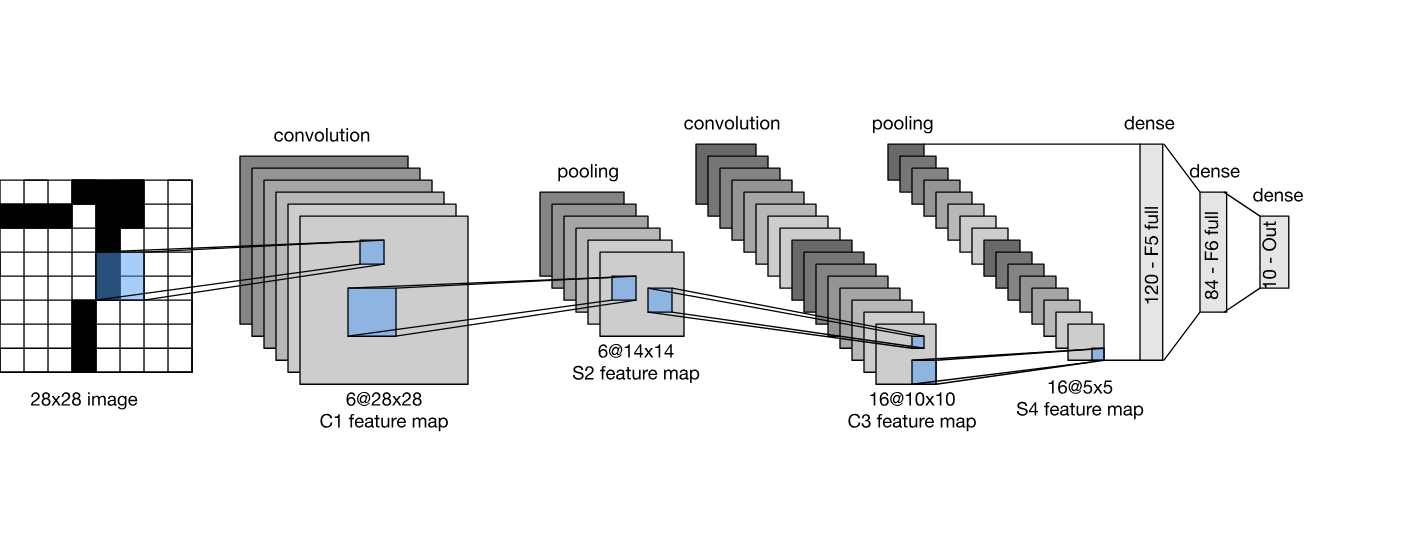

### Question 3: CNN Arithmetics

Consider these unnormalized one-input-channel $5 \times 5$ image $A$, as well as $K_1$ and $K_2$ kernels below.

$$A=\begin{bmatrix}
25 & 145 & 180 & 115 & 55 \\
20 & 190 & 195 & 180 & 155\\
215 & 215 & 45 & 250 & 235 \\
95 & 105 & 5 & 225 & 50\\
140 & 115 & 125 & 190 & 15\\
\end{bmatrix}$$


$$K_1=\begin{bmatrix}
5 & 8\\
2 & 6\\
\end{bmatrix}$$


$$K_2=\begin{bmatrix}
2 & 4 \\
1 & 2
\end{bmatrix}$$

Perform all operations mentioned below sequentially (i.e., the output of (1) becomes the input of (2), etc.) and justify the output size of each operation by comparing it to the calculation result according to the formulas defined [here](https://arxiv.org/pdf/1603.07285), e.g. **Relationship 1** in page 13 is for padding = 0 and stride = 1. For this question, all padded values are 0.



1.   Convolution using kernel $K_1$ with padding = 2 and stride = 2.
2.   Max pooling with kernel size = 2 and stride = 1.
3.   Convolution using kernel $K_1$ with padding = 3 and stride = 2.
4.   Average pooling with kernel size = 2 and stride = 2.
5.   Convolution using kernel $K_2$ with padding = 0 and stride = 1.

